Classification Project: Adult Income Prediction

Dataset: Adult Income Dataset (Kaggle)
Source: Kaggle – Adult Income Dataset
Problem: Predict whether a person's annual income is <=50K or >50K based on demographic and employment-related features.

These libraries are used to load and process data, split it into training and testing sets, and build different classification models such as Logistic Regression, Decision Tree, Random Forest, and K-Nearest Neighbors (KNN).

In [83]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier


In [84]:
df = pd.read_csv("adult.csv")

print(df.head())
print(df.shape)
print(df.info())

   age  workclass  fnlwgt     education  educational-num      marital-status  \
0   25    Private  226802          11th                7       Never-married   
1   38    Private   89814       HS-grad                9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm               12  Married-civ-spouse   
3   44    Private  160323  Some-college               10  Married-civ-spouse   
4   18          ?  103497  Some-college               10       Never-married   

          occupation relationship   race  gender  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                  ?    Own-child  White  Female             0             0   

   hours-per-week native-country incom

It helps understand the dataset, identify missing values, and check how many records belong to each income category.

In [85]:
print(df.describe(include="all"))
print(df.isnull().sum())
print(df["income"].value_counts())

                 age workclass        fnlwgt education  educational-num  \
count   48842.000000     48842  4.884200e+04     48842     48842.000000   
unique           NaN         9           NaN        16              NaN   
top              NaN   Private           NaN   HS-grad              NaN   
freq             NaN     33906           NaN     15784              NaN   
mean       38.643585       NaN  1.896641e+05       NaN        10.078089   
std        13.710510       NaN  1.056040e+05       NaN         2.570973   
min        17.000000       NaN  1.228500e+04       NaN         1.000000   
25%        28.000000       NaN  1.175505e+05       NaN         9.000000   
50%        37.000000       NaN  1.781445e+05       NaN        10.000000   
75%        48.000000       NaN  2.376420e+05       NaN        12.000000   
max        90.000000       NaN  1.490400e+06       NaN        16.000000   

            marital-status      occupation relationship   race gender  \
count                48842

It helps visualize the distribution of income classes and identify whether the classes are balanced or imbalanced.

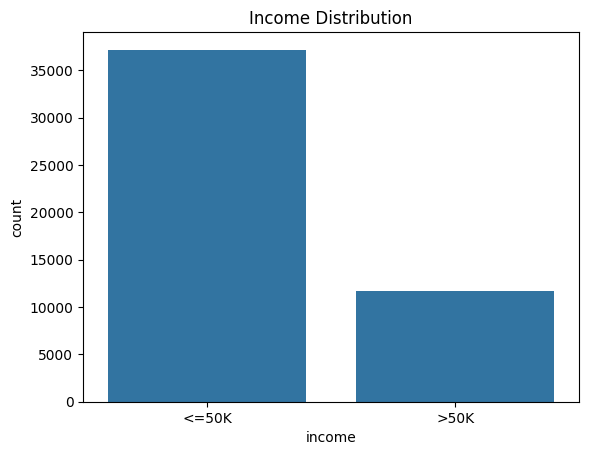

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x="income")
plt.title("Income Distribution")
plt.show()

It helps understand which age groups are most common and how the ages are distributed.

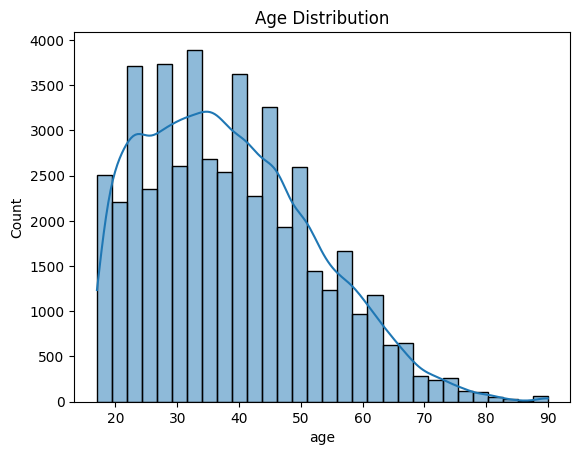

In [87]:
sns.histplot(data=df, x="age", bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

It helps visualize the relationship between education level and income, and compare the number of people earning <=50K and >50K across education levels.

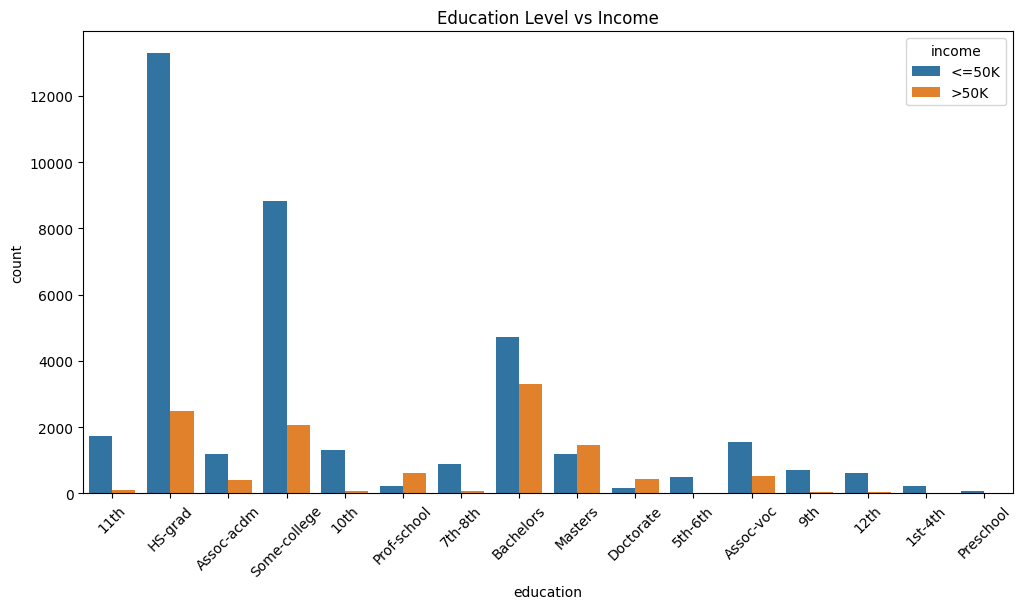

In [88]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x="education", hue="income")
plt.xticks(rotation=45)
plt.title("Education Level vs Income")
plt.show()

It helps analyze whether age and weekly working hours are related to income levels.

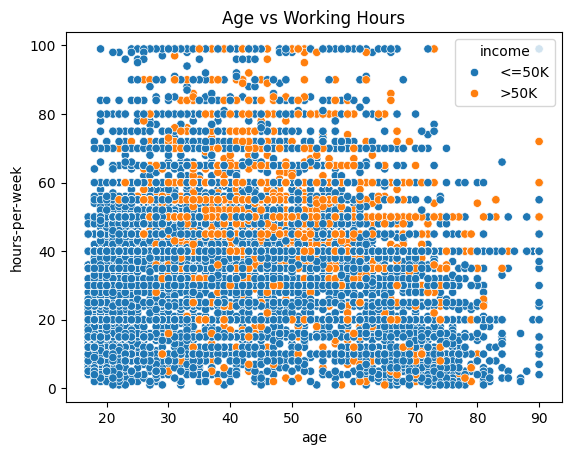

In [89]:
sns.scatterplot(data=df, x="age", y="hours-per-week", hue="income")
plt.title("Age vs Working Hours")
plt.show()

It helps compare the median, spread, and possible outliers of age between <=50K and >50K income groups.

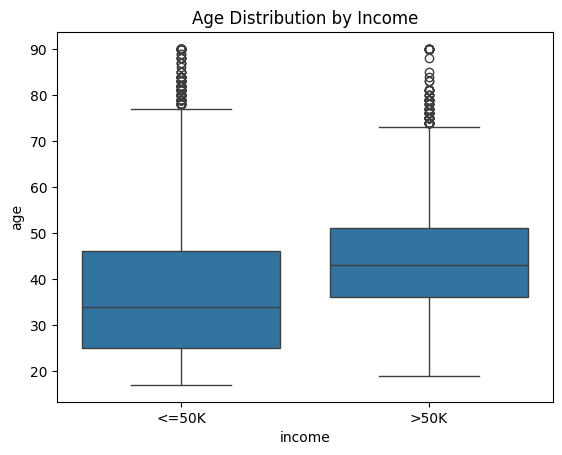

In [90]:
sns.boxplot(data=df, x="income", y="age")
plt.title("Age Distribution by Income")
plt.show()

It helps understand which workclass categories are most common and their proportion in the dataset.

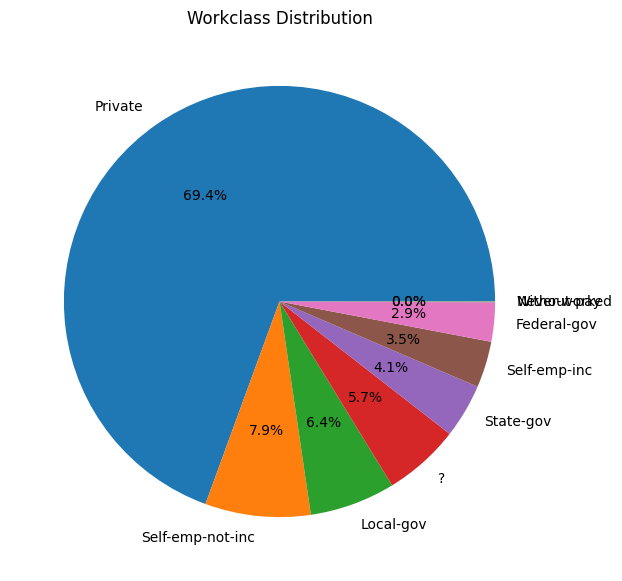

In [91]:
df["workclass"].value_counts().plot.pie(
    autopct="%1.1f%%",
    figsize=(7,7)
)
plt.title("Workclass Distribution")
plt.ylabel("")
plt.show()

It helps identify positive or negative relationships between numerical features and understand which variables may be related.

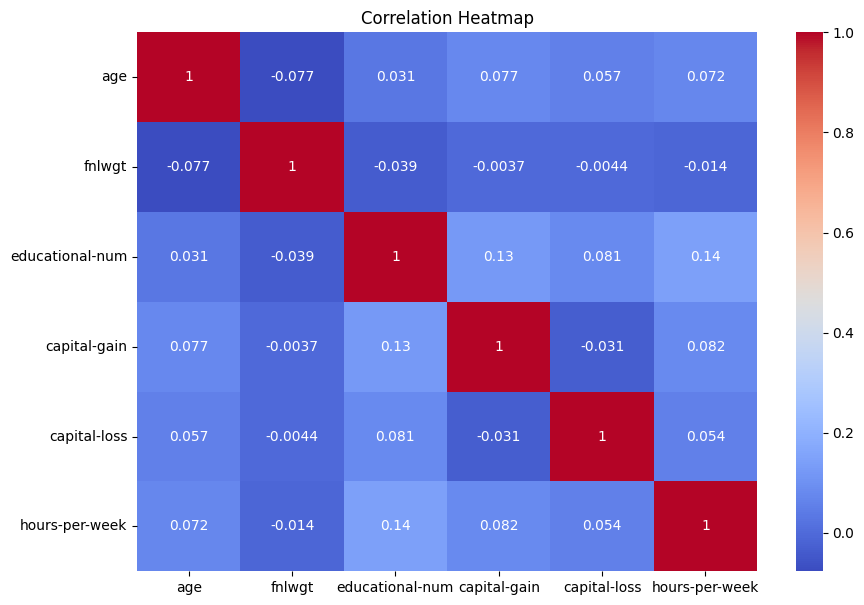

In [92]:
numeric_cols = df.select_dtypes(include="number")

plt.figure(figsize=(10,7))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Data Cleaning

The Adult dataset commonly contains missing/unknown values represented by ?.

In [93]:
df = df.replace("?", pd.NA)

print(df.isnull().sum())

df = df.dropna()
df = df.drop_duplicates()

print(df.shape)

age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64
(45175, 15)


It helps detect unusually low or high age values that may be considered outliers.

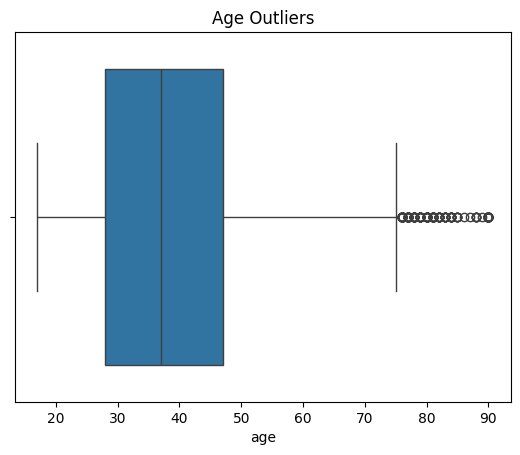

In [94]:
sns.boxplot(data=df, x="age")
plt.title("Age Outliers")
plt.show()

Feature Engineering

Create useful features from existing columns:
This code creates two new features: capital_net, which calculates net capital gain/loss, and age_group, which divides people into four age categories.
For the model, use useful demographic, education, work, and financial feature

In [95]:
df["capital_net"] = df["capital-gain"] - df["capital-loss"]

df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 25, 40, 60, 100],
    labels=["Young", "Adult", "Middle Age", "Senior"]
)
print(df["capital_net"])
print(df["age_group"])

0            0
1            0
2            0
3         7688
5            0
         ...  
48837        0
48838        0
48839        0
48840        0
48841    15024
Name: capital_net, Length: 45175, dtype: int64
0             Young
1             Adult
2             Adult
3        Middle Age
5             Adult
            ...    
48837         Adult
48838         Adult
48839    Middle Age
48840         Young
48841    Middle Age
Name: age_group, Length: 45175, dtype: category
Categories (4, object): ['Young' < 'Adult' < 'Middle Age' < 'Senior']


Vectorization / Encoding

Because the dataset contains categorical text values, we need to convert them into numerical form.Use One-Hot Encoding

In [96]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

Scaling

Numerical features can be standardized:
This is particularly useful for models such as Logistic Regression and KNN

In [97]:
from sklearn.preprocessing import StandardScaler

Model Training

we have to compare multiple classification algorithms:

Logistic Regression
Decision Tree
Random Forest
KNN

In [98]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [99]:
# Features (input)
X = df.drop("income", axis=1)

# Target (output)
y = df["income"]

Validation & Testing

Use an 80/20 train-test split:
This code splits the dataset into 80% training data and 20% testing data, while stratify=y keeps the same proportion of income classes in both sets.

In [100]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (36140, 16)
X_test: (9035, 16)
y_train: (36140,)
y_test: (9035,)


In [101]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier()
}

The Adult Income Dataset from Kaggle is a classification dataset used to predict whether a person's annual income is <=50K or >50K based on demographic, education, employment, and financial features. The dataset was loaded and inspected using statistical summaries, missing-value checks, duplicate checks, and exploratory data analysis. EDA was performed using count plots, histograms, bar charts, scatter plots, box plots, pie charts, and a correlation heatmap.

During data cleaning, unknown values represented by '?' were handled, missing records and duplicates were removed, and numerical features were checked for outliers. Feature engineering was performed where useful, and categorical variables were converted into numerical values using One-Hot Encoding. Numerical features were standardized where required.

Multiple classification models, including Logistic Regression, Decision Tree, Random Forest, and KNN, were trained and evaluated using a stratified train-test split. Accuracy, Precision, Recall, F1-score, and Confusion Matrix were used for model evaluation and comparison. The selected trained pipeline was saved using Joblib and can be used in a Streamlit GUI for predicting income categories from new user input.

The analysis helps identify how factors such as education, age, occupation, working hours, and other demographic and employment characteristics are associated with the income classification in this dataset.
